In [1]:
import config as cfg
import numpy as np
import matplotlib.pyplot as plt
from efficiency_finder import get_efficiencies, get_sample_expectations
import os
from glob import glob
import uproot
import awkward as ak
import matplotlib as mpl
import efficiency_finder

In [2]:
##################
#Get data at wp1
##################
folder = 'outputs/stage2'
files = {sample: glob(os.path.join(folder, sample, '*.root')) for sample in cfg.samples}
  
#cuts from config at current working point
cutforms = [f'{key}>={value}' for key, value in cfg.wp1_cuts.items()]
#putting cuts in correct format
eff_cut=str(f'({cutforms[0]})')
for i in np.arange(1,len(cutforms),1):
    eff_cut += str(f' & ({cutforms[i]})')

eff_cut

'(EVT_MVA1>=0.994) & (EVT_MVA2>=0.95)'

In [3]:
data = {}
for sample in cfg.samples:
    tree = [f'{f}:events' for f in files[sample]]
    data[sample] = uproot.concatenate(tree, expressions='EVT_MVA2', cut=eff_cut)['EVT_MVA2']

data

{'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': <Array [0.999, 0.996, 0.999, ..., 0.991, 0.992, 0.996] type='595606 * float32'>,
 'p8_ee_Zbb_ecm91': <Array [0.983, 0.97, 0.955, ..., 0.999, 0.955, 0.974] type='734 * float32'>,
 'p8_ee_Zcc_ecm91': <Array [0.987, 0.958, 0.955, ..., 0.979, 0.976, 0.991] type='671 * float32'>,
 'p8_ee_Zss_ecm91': <Array [0.96, 0.985, 0.982, ..., 0.981, 0.982, 0.955] type='1207 * float32'>,
 'p8_ee_Zud_ecm91': <Array [0.996, 0.959, 0.987, ..., 0.965, 0.976, 0.967] type='145 * float32'>}

In [4]:
###################
#Set up histogram
###################

hist_bins = np.arange(0.95,1.,0.01)

sig, bins = np.histogram(data['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], bins=hist_bins) #np.histogram range: range(float, float), optional. The lower and upper range of the bins. If not provided, range is simply (a.min(), a.max())
bb, bins  = np.histogram(data['p8_ee_Zbb_ecm91'], bins=hist_bins)
cc, bins  = np.histogram(data['p8_ee_Zcc_ecm91'], bins=hist_bins)
ss, bins  = np.histogram(data['p8_ee_Zss_ecm91'], bins=hist_bins)
ud, bins  = np.histogram(data['p8_ee_Zud_ecm91'], bins=hist_bins)

bb_err = np.sqrt(bb)
cc_err = np.sqrt(cc)
ss_err = np.sqrt(ss)
ud_err = np.sqrt(ud)
sig_err = np.sqrt(sig)


In [5]:
bins

<Array [0.95, 0.96, 0.97, 0.98, 0.99, 1] type='6 * float64'>

In [6]:
cut_expr = []
for i in range(len(bins)):
    if (i+1) == len(bins):
        break
    elif (i+2) == len(bins):
        cut_expr.append(f'({cutforms[0]}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 <= {bins[i+1]})')
    else:
        cut_expr.append(f'({cutforms[0]}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 < {bins[i+1]})')

cut_expr

['(EVT_MVA1>=0.994) & (EVT_MVA2 >= 0.95) & (EVT_MVA2 < 0.96)',
 '(EVT_MVA1>=0.994) & (EVT_MVA2 >= 0.96) & (EVT_MVA2 < 0.97)',
 '(EVT_MVA1>=0.994) & (EVT_MVA2 >= 0.97) & (EVT_MVA2 < 0.98)',
 '(EVT_MVA1>=0.994) & (EVT_MVA2 >= 0.98) & (EVT_MVA2 < 0.99)',
 '(EVT_MVA1>=0.994) & (EVT_MVA2 >= 0.99) & (EVT_MVA2 <= 1.0)']

In [7]:
effs = efficiency_finder.get_efficiencies('stage2', cut=cut_expr, raw=True, verbose=False)
nums = efficiency_finder.get_sample_expectations(effs, 1e-5, verbose=False, cut=cut_expr)

tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
var = np.zeros_like(nums['p8_ee_Zbb_ecm91_err'])
for sample in cfg.samples:
    if sample in cfg.sample_allocations['background']:
        tot += nums[sample+'_num']
        var += nums[sample+'_err']**2

tot_err = np.sqrt(var)


In [8]:
reds = mpl.colormaps['Reds_r']
cols = reds(np.linspace(0, 1, 8)[2:-2])


bin_centres = (bins[:-1]+bins[1:])/2

bins[:-1]

<Array [0.95, 0.96, 0.97, 0.98, 0.99] type='5 * float64'>

In [9]:
np.diff(bins)

<Array [0.01, 0.01, 0.01, 0.01, 0.01] type='5 * float64'>

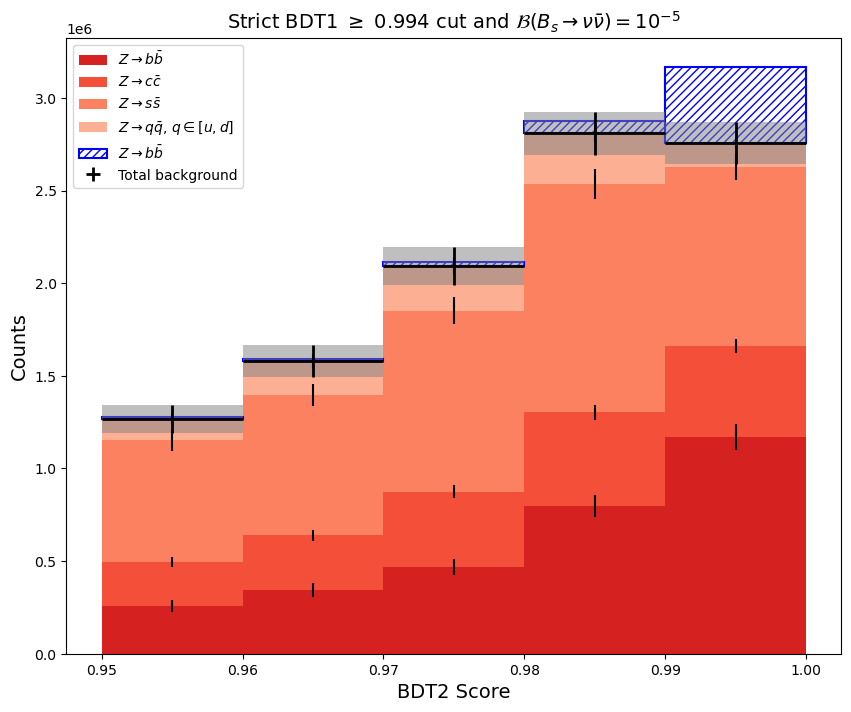

In [10]:
bin_centres = (bins[:-1]+bins[1:])/2
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], width=np.diff(bins), align='center', color=cols[0], label=cfg.titles['p8_ee_Zbb_ecm91'])
ax.bar(bin_centres, nums['p8_ee_Zcc_ecm91_num'], width=np.diff(bins), align='center', color=cols[1], 
       label=cfg.titles['p8_ee_Zcc_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zss_ecm91_num'], width=np.diff(bins), align='center', color=cols[2], 
       label=cfg.titles['p8_ee_Zss_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zud_ecm91_num'], width=np.diff(bins), align='center', color=cols[3], 
       label=cfg.titles['p8_ee_Zud_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zss_ecm91_num'])

ax.errorbar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zbb_ecm91_err'], fmt='None', ecolor='black')
ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zcc_ecm91_err'], fmt='None', ecolor='black')
ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num'], yerr=nums['p8_ee_Zss_ecm91_err'], fmt='None', ecolor='black')
ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num']+nums['p8_ee_Zud_ecm91_num'], yerr=nums['p8_ee_Zud_ecm91_err'], fmt='None', ecolor='black')

ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num'], width=np.diff(bins), align='center', 
       edgecolor='blue', hatch='////', facecolor='none', 
       linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91'],
       bottom=tot)
ax.errorbar(bin_centres, tot, xerr=0.5*np.diff(bins), yerr=tot_err, fmt='None', ecolor='black', elinewidth=2, label='Total background')
ax.bar(bin_centres, 2*tot_err, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=tot-tot_err)

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
#plt.savefig('/usera/rrm42/private/predict.pdf', dpi=600)
plt.show()


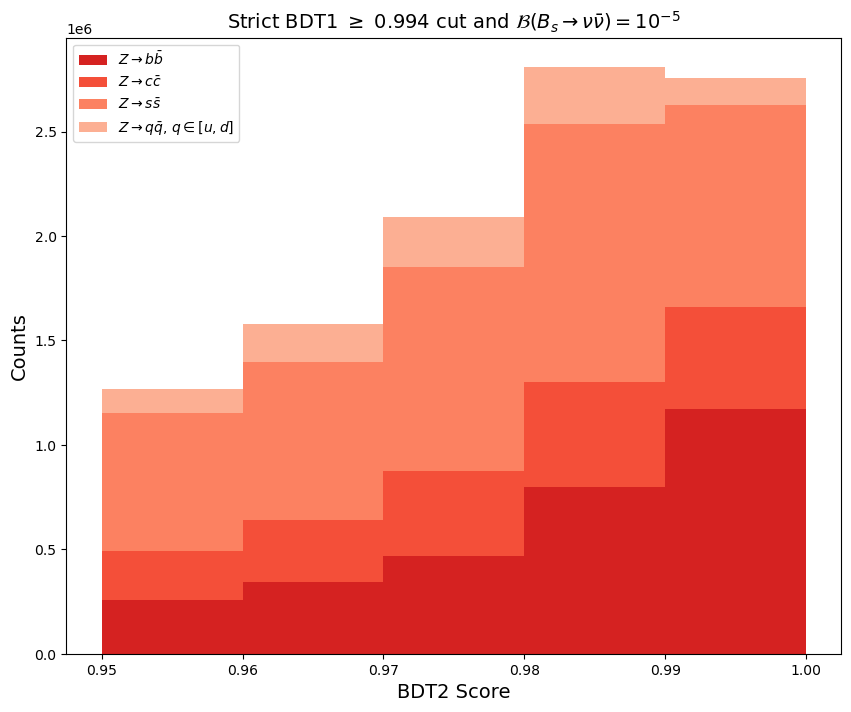

In [11]:
bin_centres = (bins[:-1]+bins[1:])/2
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], width=np.diff(bins), align='center', color=cols[0], label=cfg.titles['p8_ee_Zbb_ecm91'])
ax.bar(bin_centres, nums['p8_ee_Zcc_ecm91_num'], width=np.diff(bins), align='center', color=cols[1], 
       label=cfg.titles['p8_ee_Zcc_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zss_ecm91_num'], width=np.diff(bins), align='center', color=cols[2], 
       label=cfg.titles['p8_ee_Zss_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num'])
ax.bar(bin_centres, nums['p8_ee_Zud_ecm91_num'], width=np.diff(bins), align='center', color=cols[3], 
       label=cfg.titles['p8_ee_Zud_ecm91'], bottom=nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zss_ecm91_num'])

#ax.errorbar(bin_centres, nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zbb_ecm91_err'], fmt='None', ecolor='black')
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num'], yerr=nums['p8_ee_Zcc_ecm91_err'], fmt='None', ecolor='black')
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num'], yerr=nums['p8_ee_Zss_ecm91_err'], fmt='None', ecolor='black')
#ax.errorbar(bin_centres, nums['p8_ee_Zcc_ecm91_num']+nums['p8_ee_Zbb_ecm91_num']+nums['p8_ee_Zss_ecm91_num']+nums['p8_ee_Zud_ecm91_num'], yerr=nums['p8_ee_Zud_ecm91_err'], fmt='None', ecolor='black')

#ax.bar(bin_centres, nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num'], width=np.diff(bins), align='center', 
       #edgecolor='blue', hatch='////', facecolor='none', 
       #linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91'],
       #bottom=tot)
#ax.errorbar(bin_centres, tot, xerr=0.5*np.diff(bins), yerr=tot_err, fmt='None', ecolor='black', elinewidth=2, label='Total background')
#ax.bar(bin_centres, 2*tot_err, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=tot-tot_err)

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
#plt.savefig('/usera/rrm42/private/predict.pdf', dpi=600)
plt.show()

In [12]:
varname='EVT_MVA2'
signal_bf=1e-5
cut= '(EVT_MVA1>=0.994)&(EVT_MVA2>=0.95)'
components=["signal", "background"]
bins=5
effs = efficiency_finder.get_efficiencies(inputtype='stage2', cut=cut, raw=True)
n_expect = efficiency_finder.get_sample_expectations(effs, signal_bf, save=None, cut=cut)


------------------------------
EFFICIENCY CALCULATOR
------------------------------

Initialising...
----> INFO: Using files from:
               /r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2/
----> INFO: With cut (EVT_MVA1>=0.994)&(EVT_MVA2>=0.95)
----> INFO: Calculating TOTAL efficiency (from eventsProcessed)

------------------------------

----> INFO: `samples` either 'all' or invalid, using all config.samples
----> INFO: Using None files from each sample

------------------------------

p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu with cut (EVT_MVA1>=0.994)&(EVT_MVA2>=0.95):
               n_events processed = 2000000
               n_events selected  = 595606
               Efficiency         = (2.978 +/- 0.003) x 10^-1

p8_ee_Zbb_ecm91 with cut (EVT_MVA1>=0.994)&(EVT_MVA2>=0.95):
               n_events processed = 219418366
               n_events selected  = 734
               Efficiency         = (3.345 +/- 0.124) x 10^-6

p8_ee_Zcc_ecm91 with cut (EVT_MVA1>=0

In [13]:
#path = os.path.join( os.path.abspath(f'./outputs/stage2/{sample}/'), "*.root:events" )
#arr = uproot.concatenate( path, expressions=varname, cut=cut)[varname]
#path

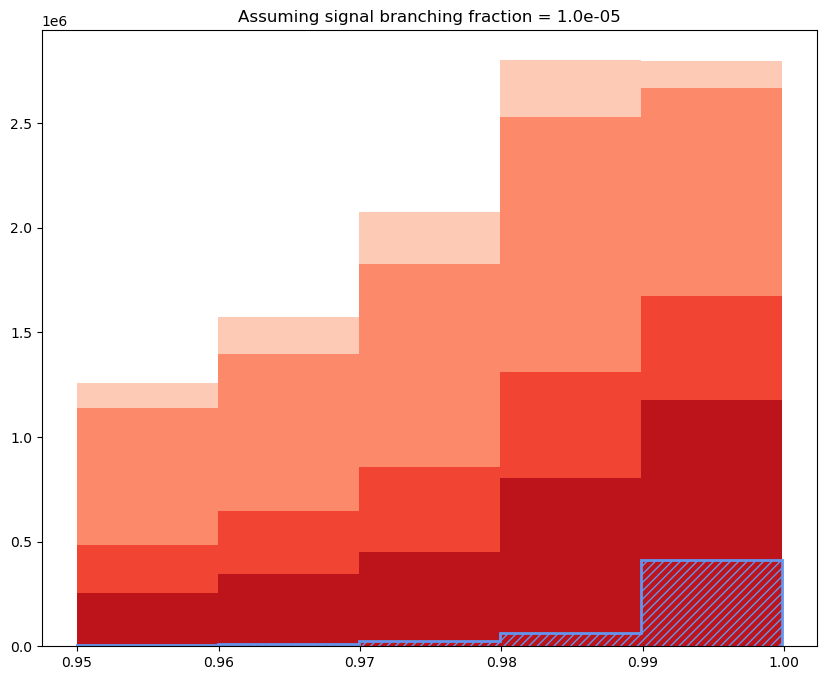

In [14]:
bins=5
fig, ax = plt.subplots(figsize=(10,8))
values = { sample: uproot.concatenate( os.path.join( os.path.abspath(f'./outputs/stage2/{sample}/'), "*.root:events" ), expressions=varname, cut=cut)[varname] for sample in cfg.samples }

for allocation in cfg.sample_allocations:
    if allocation not in components:
        continue
    samples = cfg.sample_allocations[allocation]
    hist_x = [ values[sample] for sample in samples ]
    #want weight
    hist_w = [ np.ones_like(values[sample])*n_expect[sample+'_num']/len(values[sample]) for sample in samples ]

    hist_l = [ cfg.titles[sample] for sample in samples ]
    #want stacked
    hist_opts = dict( stacked=True, histtype='stepfilled', alpha=1 )

    if allocation=='signal':
        hist_opts['histtype'] = 'step'
        hist_opts['lw'] = 2
        hist_opts['color'] = 'cornflowerblue'
        hist_opts['hatch'] = '////'
    elif allocation=='background':
        reds = mpl.colormaps['Reds_r']
        hist_opts['color'] = reds( np.linspace(0, 1, len(samples)+2)[1:-1] )

    xmin = min( [ min(values[sample]) for sample in values ] )
    xmax = max( [ max(values[sample]) for sample in values ] )
    
    ax.hist( 
        x = hist_x,
        bins = bins,
        range = (xmin,xmax),
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )
ax.set_title(f'Assuming signal branching fraction = {signal_bf:.1e}')

plt.show()

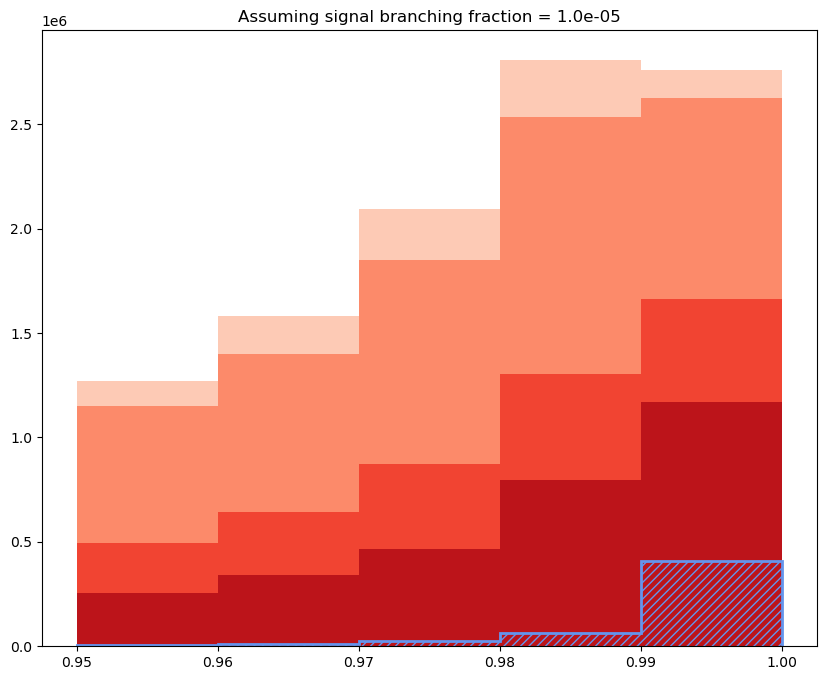

In [16]:
bins=5
fig, ax = plt.subplots(figsize=(10,8))
values = { sample: uproot.concatenate( os.path.join( os.path.abspath(f'./outputs/stage2/{sample}/'), "*.root:events" ), expressions=varname, cut=cut)[varname] for sample in cfg.samples }

for allocation in cfg.sample_allocations:
    if allocation not in components:
        continue
    samples = cfg.sample_allocations[allocation]
    hist_x = [ values[sample] for sample in samples ]
    #want weight
    hist_w = [ np.ones_like(values[sample])*n_expect[sample+'_num']/len(values[sample]) for sample in samples ]

    hist_l = [ cfg.titles[sample] for sample in samples ]
    #want stacked
    hist_opts = dict( stacked=True, histtype='stepfilled', alpha=1 )

    if allocation=='signal':
        hist_opts['histtype'] = 'step'
        hist_opts['lw'] = 2
        hist_opts['color'] = 'cornflowerblue'
        hist_opts['hatch'] = '////'
    elif allocation=='background':
        reds = mpl.colormaps['Reds_r']
        hist_opts['color'] = reds( np.linspace(0, 1, len(samples)+2)[1:-1] )

    xmin = min( [ min(values[sample]) for sample in values ] )
    xmax = max( [ max(values[sample]) for sample in values ] )
    
    ax.hist( 
        x = hist_x,
        bins = bins,
        range = (0.95,1),
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )
ax.set_title(f'Assuming signal branching fraction = {signal_bf:.1e}')

plt.show()

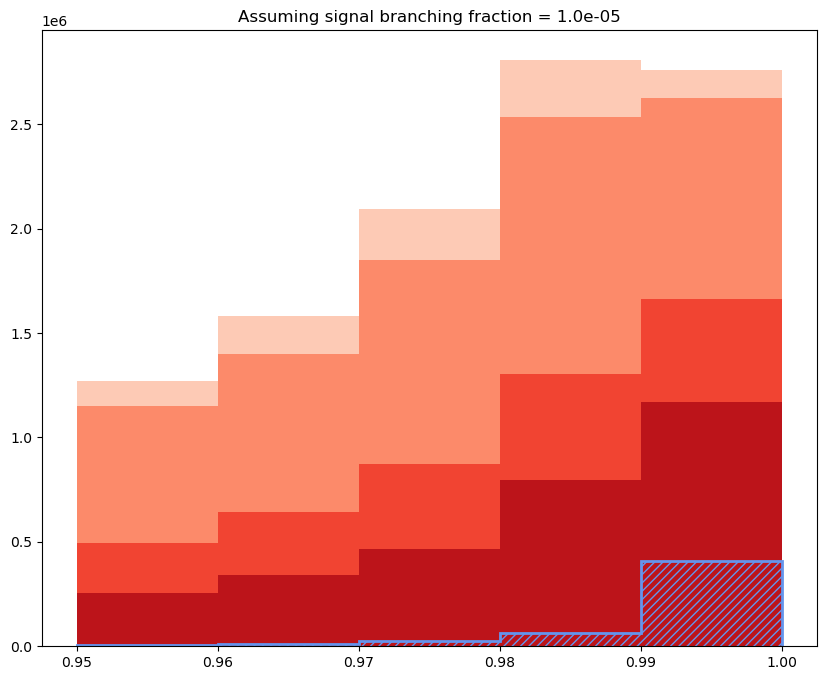

In [15]:
bins=[0.95,0.96,0.97,0.98,0.99,1.]
fig, ax = plt.subplots(figsize=(10,8))
values = { sample: uproot.concatenate( os.path.join( os.path.abspath(f'./outputs/stage2/{sample}/'), "*.root:events" ), expressions=varname, cut=cut)[varname] for sample in cfg.samples }

for allocation in cfg.sample_allocations:
    if allocation not in components:
        continue
    samples = cfg.sample_allocations[allocation]
    hist_x = [ values[sample] for sample in samples ]
    #want weight
    hist_w = [ np.ones_like(values[sample])*n_expect[sample+'_num']/len(values[sample]) for sample in samples ]

    hist_l = [ cfg.titles[sample] for sample in samples ]
    #want stacked
    hist_opts = dict( stacked=True, histtype='stepfilled', alpha=1 )

    if allocation=='signal':
        hist_opts['histtype'] = 'step'
        hist_opts['lw'] = 2
        hist_opts['color'] = 'cornflowerblue'
        hist_opts['hatch'] = '////'
    elif allocation=='background':
        reds = mpl.colormaps['Reds_r']
        hist_opts['color'] = reds( np.linspace(0, 1, len(samples)+2)[1:-1] )

    xmin = min( [ min(values[sample]) for sample in values ] )
    xmax = max( [ max(values[sample]) for sample in values ] )
    
    ax.hist( 
        x = hist_x,
        bins = bins,
        range = (xmin,xmax),
        label = hist_l,
        weights = hist_w,
        **hist_opts
    )
ax.set_title(f'Assuming signal branching fraction = {signal_bf:.1e}')

plt.show()